In [1]:
from pathlib import Path
import copy
import pandas as pd
import datetime
from datetime import datetime
from liblaf import grapes
import polars as pl


In [2]:
from qoc.market import  BinanceMarketData,BinanceDataCollectionFuturesUm
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()


# symbols: list[str] = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT', 'SPXUSDT']
symbols: list[str] = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT']
interval: str = "1m"


# start: str = "2025-04-01"
# end: str  = "2025-09-30"
    
start: str = "2025-04-01"
end: str  = "2026-02-14"
    
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()



In [3]:
with grapes.timer():

    coin_list: dict[str, pl.DataFrame] = await market_data.klines_batch(
        symbols, interval, start, end
    )

# Preload

In [4]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os


In [5]:
start_time = datetime.strptime(start, "%Y-%m-%d")
end_time = datetime.strptime(end, "%Y-%m-%d")

In [6]:
start_time = start
end_time = end

In [7]:
# coin_list: dict[str, pd.DataFrame] = {}
for symbol, df in coin_list.items():
    df = pd.DataFrame(df.to_dicts())
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms').dt.tz_localize(None)
    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms').dt.tz_localize(None)

    df.set_index('open_time', inplace=True)
    # print(df.index.min(), df.index.max())
    coin_list[symbol] = df
# coin_dict = None  # release memory

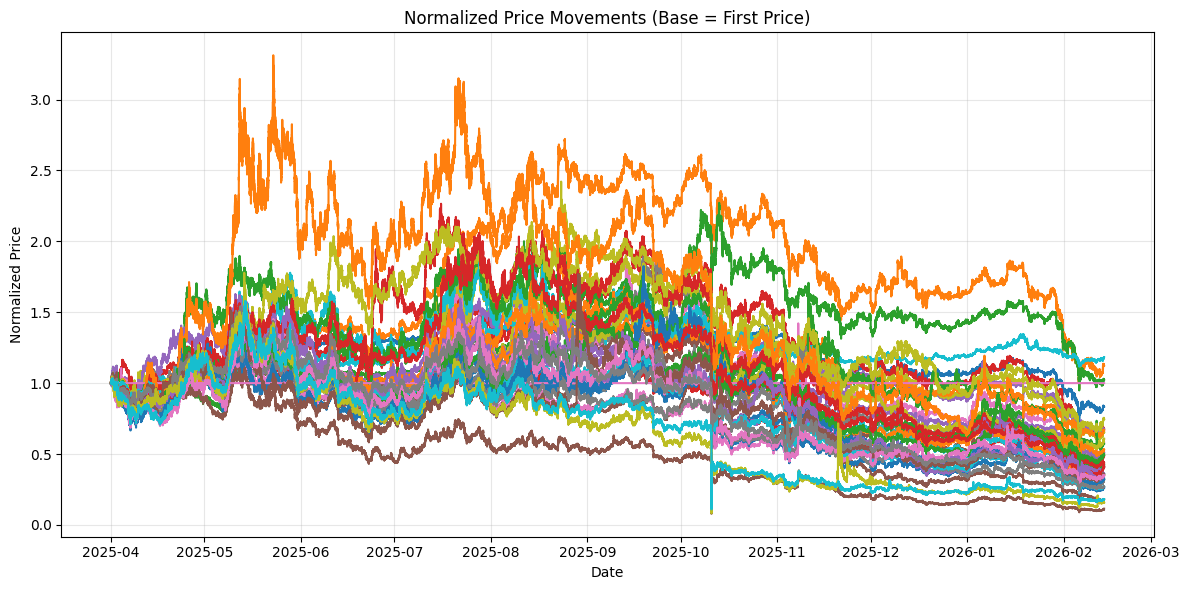

In [8]:
plt.figure(figsize=(12, 6))
for symbol, df in coin_list.items():
    if len(df) > 0:  # Check if dataframe is not empty
        # Normalize to first price
        normalized_prices = df["close"] / df["close"].iloc[0]
        plt.plot(df.index, normalized_prices, label=symbol)

plt.title('Normalized Price Movements (Base = First Price)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Para

In [9]:

FORWARD_WINDOW =60
BACK_WINDOW = 120
BULLET_SIZE = 50

# Stats

## Split

In [10]:
# Remove MATICUSDT from coin_list

if 'MATICUSDT' in coin_list:
    del coin_list['MATICUSDT']
    print("MATICUSDT removed from coin_list")
else:
    print("MATICUSDT not found in coin_list")

print(f"Remaining symbols in coin_list: {list(coin_list.keys())}")

if 'FTMUSDT' in coin_list:
    del coin_list['FTMUSDT']
    print("FTMUSDT removed from coin_list")
else:
    print("FTMUSDT not found in coin_list")

print(f"Remaining symbols in coin_list: {list(coin_list.keys())}")

MATICUSDT not found in coin_list
Remaining symbols in coin_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT']
FTMUSDT removed from coin_list
Remaining symbols in coin_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUS

In [11]:
coin_list

{'BTCUSDT':                         open     high      low    close   volume  \
 open_time                                                          
 2025-04-01 00:00:00  82517.5  82526.4  82446.4  82460.6  294.949   
 2025-04-01 00:01:00  82460.6  82490.1  82443.7  82490.1   47.283   
 2025-04-01 00:02:00  82490.1  82521.4  82459.9  82479.1   84.397   
 2025-04-01 00:03:00  82479.1  82555.7  82475.5  82552.1  142.387   
 2025-04-01 00:04:00  82552.1  82587.1  82550.0  82587.1  112.609   
 ...                      ...      ...      ...      ...      ...   
 2026-02-13 23:56:00  68868.9  68875.1  68855.2  68875.0   13.471   
 2026-02-13 23:57:00  68875.1  68897.3  68864.8  68866.6   23.097   
 2026-02-13 23:58:00  68866.8  68877.9  68858.5  68858.6    9.262   
 2026-02-13 23:59:00  68858.6  68869.4  68799.0  68821.5  181.627   
 2026-02-14 00:00:00  68821.5  68828.5  68800.0  68813.0   62.990   
 
                                  close_time  quote_volume  count  \
 open_time           

## Regress

In [12]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


# btc_close = deque(btc['close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['close'][:back_window], maxlen=back_window) for name, df in coin_list.items()}


# btc_volume = deque(btc['volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['volume'][:back_window], maxlen=back_window) for name, df in coin_list.items()}


xy_1 = {name: deque(np.array([0]*back_window)) for name in coin_list.keys()}
xx_1 = {name: deque(np.array([0]*back_window)) for name in coin_list.keys()}
yy_1 = {name: deque(np.array([0]*back_window)) for name in coin_list.keys()}
x_1 = {name: deque(np.array([0]*back_window)) for name in coin_list.keys()}
y_1 = {name: deque(np.array([0]*back_window)) for name in coin_list.keys()}


xy_1_sum = {name: 0 for name in coin_list.keys()}
xx_1_sum = {name: 0 for name in coin_list.keys()}
yy_1_sum = {name: 0 for name in coin_list.keys()}
x_1_sum = {name: 0 for name in coin_list.keys()}
y_1_sum = {name: 0 for name in coin_list.keys()}

# Trade

In [13]:
lc = None
sc = None
sam = 0
dif = 0

In [14]:
windows = [0.25, 0.5 , 1, 4, 16, 64, 256]
for i in range(len(windows)):
    windows[i] = int(BACK_WINDOW*windows[i])
windows

[30, 60, 120, 480, 1920, 7680, 30720]

In [15]:
# Initialize coef_records
coef_records = {}

revenues = []
revenues_filtered = []

# regression stats
    # Residual difference between short and long
    # Residual mean/std

    # Residual z-score all
    # Residual z-score selected
    # Residual sign

    # corr all
    # corr selected

stats_global = {
    "residual_diff": [],
    "residual_std": [],
    "residual_mean": [],
    "residual_z_all": [],
    "residual_z_selected": [],
    "residual_z_selected_mns": [],
    "residual_sign": [],
    "corr_all": [],
    "corr_selected": [],
    "corr_selected_mns": [],
    "coef_adj_all": [],
    "coef_adj_selected": [],
    "coef_adj_selected_mns": [],
}


# stats by windows
    # growth diff all
    # growth diff selected
    # growth diff sign

    # Amihud all
    # Amihud selected

    # CMI all
    # CMI selected

    # coin score all
    # coin score selected

    # ATR all
    # ATR selected

    # Bollinger Bands all
    # Bollinger Bands selected

    # Volatility all
    # Volatility selected

stats_list = [
    "close_ret",
    "amihud",
    "cmi",
    "coin",
    "atr",
    "bb",
    "std",
]


stats_by_window = {}

for stat in stats_list:
    for scope in ["all", "selected", "selected_mns"]:
        key = f"{stat}_{scope}"
        stats_by_window[key] = {w: [] for w in windows}


## Coin_score
temp_revs= {name: deque([0] * (forward_window + 1), maxlen=forward_window + 1) for name in coin_list.keys()}

coin_scores = {name: {w: 0 for w in windows} for name in coin_list.keys()}


In [16]:
stats_nocs_list = [
    "close_ret",
    "amihud",
    "cmi",
    "atr",
    "bb",
    "std",
]

In [17]:
for tqdm_idx, (symbol, df) in tqdm(enumerate(coin_list.items())):

    df = df.copy()
    ## growth
    for w in windows:
        df[f"close_ret_{w}"] = (
            np.log(df["close"])
            - np.log(df["close"].shift(w))
        )
    ## Amihud
    for w in windows:
        df[f"amihud_{w}"] = (
            np.log(df["close"])
            .diff()
            .abs()
            .rolling(w, min_periods=w)
            .sum()
            /
            (df["close"] * df["volume"])
            .rolling(w, min_periods=w)
            .sum()
        )
        
    ## CMI
    for w in windows:
        tr = np.maximum(
            df["high"] - df["low"],
            np.maximum(
                (df["high"] - df["close"].shift(1)).abs(),
                (df["low"]  - df["close"].shift(1)).abs()
            )
        )
        df[f"cmi_{w}"] = (
            100.0
            * np.log10(
                tr.rolling(w, min_periods=w).sum()
                /
                (
                    df["high"].rolling(w, min_periods=w).max()
                    - df["low"].rolling(w, min_periods=w).min()
                )
            )
            / np.log10(w)
        )

    ## ATR
    for w in windows:
        tr = np.maximum(
        df["high"] - df["low"],
        np.maximum(
            (df["high"] - df["close"].shift(1)).abs(),
            (df["low"]  - df["close"].shift(1)).abs()
        )
        )

        df[f"atr_{w}"] = tr.rolling(w, min_periods=w).mean()/ df["close"]

    ## Bollinger
    for w in windows:
        df[f"bb_{w}"] = (
            (
                df["close"]
                -
                df["close"].rolling(w, min_periods=w).mean()
            )
            /
            df["close"].rolling(w, min_periods=w).std()
        )
    ## Std
    for w in windows:
        df[f"std_{w}"] = (
            np.log(df["close"]).diff()
            .rolling(w, min_periods=w)
            .std()
        )
    df.dropna(inplace=True)           

    coin_list[symbol] = df


0it [00:00, ?it/s]

39it [00:42,  1.09s/it]


In [18]:
coin_list['DOGEUSDT']['amihud_30']

open_time
2025-04-22 08:00:00    7.482647e-10
2025-04-22 08:01:00    9.218571e-10
2025-04-22 08:02:00    9.244704e-10
2025-04-22 08:03:00    9.649126e-10
2025-04-22 08:04:00    1.031166e-09
                           ...     
2026-02-13 23:56:00    3.439968e-09
2026-02-13 23:57:00    3.580950e-09
2026-02-13 23:58:00    3.435226e-09
2026-02-13 23:59:00    3.387773e-09
2026-02-14 00:00:00    3.251115e-09
Name: amihud_30, Length: 428641, dtype: float64

In [19]:
X_train = pd.read_csv("X_train_1.csv", index_col=0)
y_train = pd.read_csv("y_train_1.csv", index_col=0)

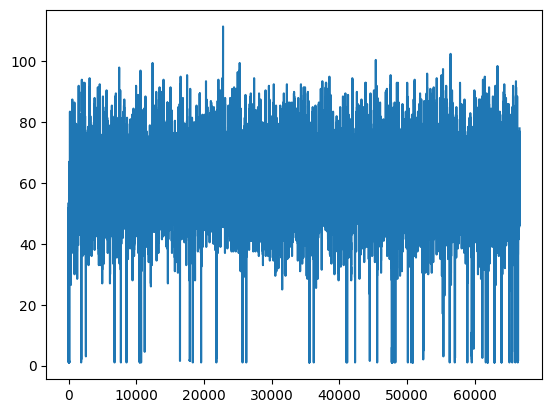

In [20]:
x= X_train['residual_z_selected'].reset_index(drop=True)
plt.plot(x)

In [21]:
y = pd.read_csv("y_train_1.csv")["y_train"].values  # 提取数值数组


In [22]:


split_date = datetime(2025, 12, 18)

# train_list = {}
# test_list = {}

for symbol, df in coin_list.items():
    # train_list[symbol] = df[df.index < split_date]
    coin_list[symbol] = df[df.index >= split_date]
data_list = coin_list


In [23]:
coin_scores

{'BTCUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ETHUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'BNBUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'SOLUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'XRPUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ADAUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'DOGEUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'AVAXUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'LINKUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'TRXUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'DOTUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'LTCUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'UNIUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0, 30720: 0},
 'ATOMUSDT': {30: 0, 60: 0, 120: 0, 480: 0, 1920: 0, 7680: 0,

In [24]:
import warnings
warnings.filterwarnings('ignore')

In [25]:

common_index = None
for symbol, df in data_list.items():
    if common_index is None:
        common_index = df.index
    else:
        common_index = common_index.intersection(df.index)

In [26]:
common_index

DatetimeIndex(['2025-12-18 00:00:00', '2025-12-18 00:01:00',
               '2025-12-18 00:02:00', '2025-12-18 00:03:00',
               '2025-12-18 00:04:00', '2025-12-18 00:05:00',
               '2025-12-18 00:06:00', '2025-12-18 00:07:00',
               '2025-12-18 00:08:00', '2025-12-18 00:09:00',
               ...
               '2026-02-13 23:51:00', '2026-02-13 23:52:00',
               '2026-02-13 23:53:00', '2026-02-13 23:54:00',
               '2026-02-13 23:55:00', '2026-02-13 23:56:00',
               '2026-02-13 23:57:00', '2026-02-13 23:58:00',
               '2026-02-13 23:59:00', '2026-02-14 00:00:00'],
              dtype='datetime64[ns]', name='open_time', length=83521, freq=None)

In [27]:
import pickle
model_trained = pickle.load(open('random_forest_model.pkl', 'rb'))

feature_order = model_trained.feature_names_in_.tolist()


In [28]:
feature_order

['residual_diff',
 'residual_std',
 'residual_mean',
 'residual_z_all',
 'residual_z_selected',
 'residual_sign',
 'corr_all',
 'corr_selected',
 'coef_adj_all',
 'coef_adj_selected',
 'close_ret_all_w30',
 'close_ret_all_w60',
 'close_ret_all_w120',
 'close_ret_all_w480',
 'close_ret_all_w1920',
 'close_ret_all_w7680',
 'close_ret_all_w30720',
 'close_ret_selected_w30',
 'close_ret_selected_w60',
 'close_ret_selected_w120',
 'close_ret_selected_w480',
 'close_ret_selected_w1920',
 'close_ret_selected_w7680',
 'close_ret_selected_w30720',
 'amihud_all_w30',
 'amihud_all_w60',
 'amihud_all_w120',
 'amihud_all_w480',
 'amihud_all_w1920',
 'amihud_all_w7680',
 'amihud_all_w30720',
 'amihud_selected_w30',
 'amihud_selected_w60',
 'amihud_selected_w120',
 'amihud_selected_w480',
 'amihud_selected_w1920',
 'amihud_selected_w7680',
 'amihud_selected_w30720',
 'cmi_all_w30',
 'cmi_all_w60',
 'cmi_all_w120',
 'cmi_all_w480',
 'cmi_all_w1920',
 'cmi_all_w7680',
 'cmi_all_w30720',
 'cmi_selected_

In [29]:


for i, t in tqdm(enumerate(common_index), desc="Processing timestamps", total=len(common_index)):
    # Only access data if timestamp exists in all dataframes
    for name, df in data_list.items():
        if t in df.index:
            coin_closes[name].append(df.loc[t, "close"])
            coin_volumes[name].append(df.loc[t, "volume"])
        else:
            print(f"Timestamp {t} not found in {name}, skipping...")
            continue

    if i>=back_window:
        for name, _ in data_list.items():
            if t not in data_list[name].index:
                continue
                
            # growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 
            # mkt_idx_diff = coin_closes['BTCUSDT'][-1] - coin_closes['BTCUSDT'][-2]                
            growth = (np.array(coin_closes[name])[-1]) 
            mkt_idx_diff = coin_closes['BTCUSDT'][-1]
            
            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

                xy_1[name].popleft()
                xx_1[name].popleft()
                yy_1[name].popleft()
                x_1[name].popleft()
                y_1[name].popleft()

            xy_1[name].append(growth*mkt_idx_diff)
            xx_1[name].append(mkt_idx_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_diff)
            y_1[name].append(growth)
            
            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            
            if i >= 2*back_window:
                # Without intercept
                coef_1 = xy_1_sum[name]/xx_1_sum[name] if xx_1_sum[name]!=0 else 0
                residual = np.array(coin_closes[name])[-1] - (coef_1 * (np.array(coin_closes['BTCUSDT'])[-1]))

                # # # With intercept
                # coef_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / (back_window * xx_1_sum[name] - x_1_sum[name]**2) if (back_window * xx_1_sum[name] - x_1_sum[name]**2) != 0 else 0
                # alpha = (y_1_sum[name] - coef_1 * x_1_sum[name]) / back_window if back_window != 0 else 0
                # residual = np.array(coin_closes[name])[-1] - (coef_1 * np.array(coin_closes['BTCUSDT'])[-1] + alpha)

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0


                y = np.asarray(coin_closes[name], dtype=float)
                x = np.asarray(coin_closes["BTCUSDT"], dtype=float)
                if coef_1 != 0:
                    residual_series = (y - coef_1 * x) / coef_1
                else:
                    residual_series = pd.Series(0.0, index=y.index)
                x = residual_series[-1]
                residual_z = np.sum(residual_series < x) + 1

                coef_records.setdefault(name, {})

                # 2. 填充 stat_w
                for stat in stats_nocs_list:
                    for w in windows:
                        stat_col = f"{stat}_{w}"
                        coef_records[name][stat_col] = (
                            data_list[name].loc[t, stat_col]
                            if stat_col in data_list[name].columns
                            else 0
                        )

                # 3. 再补充回归 / 价格字段（不会覆盖）
                coef_records[name].update({
                    'close': data_list[name].loc[t, "close"],
                    'coef_1': coef_1,
                    'coef_1_adj': (
                        coef_1
                        * np.array(coin_closes['BTCUSDT'])[-1]
                        / np.array(coin_closes[name])[-1]
                        if np.array(coin_closes[name])[-1] != 0
                        else 0
                    ),
                    'corr_1': corr_1,
                    'residual': (
                        residual / coef_1 / np.array(coin_closes['BTCUSDT'])[-1]
                        if coef_1 != 0
                        else 0
                    ),
                    'residual_z': residual_z,
                })

        if i >= 2*back_window and len(coef_records) > 1:
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index', dtype=float)  # index=coin
            
            # Select coins based on residual values
            long_coin = coef_df.sort_values(by='residual', ascending=True).index[0]
            short_coin = coef_df.sort_values(by='residual', ascending=False).index[0]

            if lc is None:
                lc = long_coin
                sc = short_coin
            if long_coin != lc:
                lc = long_coin
                dif += 1
            else:
                sam += 1
            if short_coin != sc:
                sc = short_coin
                dif += 1
            else:
                sam += 1

            # 先获取当前价格
            price_long_now = float(coef_df.loc[long_coin, 'close'])
            price_short_now = float(coef_df.loc[short_coin, 'close'])

            # 安全地获取未来价格
            future_long_price = price_long_now  # 默认值
            future_short_price = price_short_now  # 默认值

            residual_diff = float(coef_df.loc[long_coin, 'residual']) - float(coef_df.loc[short_coin, 'residual'])
            residual_mean = coef_df['residual'].mean()
            residual_std = coef_df['residual'].std()
            residual_z_all = coef_df['residual_z'].mean()
            residual_z_selected = (float(coef_df.loc[long_coin, 'residual_z']) + float(coef_df.loc[short_coin, 'residual_z'])) / 2
            residual_z_selected_mns = ((float(coef_df.loc[long_coin, 'residual_z']) - residual_z_all) + (float(coef_df.loc[short_coin, 'residual_z']) - residual_z_all)) / 2
            residual_sign = np.abs((coef_df['residual'] > 0).sum()-0.5*len(coef_df))
            corr_all = coef_df['corr_1'].mean()
            corr_selected = (float(coef_df.loc[long_coin, 'corr_1']) + float(coef_df.loc[short_coin, 'corr_1'])) / 2
            corr_selected_mns = ((float(coef_df.loc[long_coin, 'corr_1']) - corr_all) + (float(coef_df.loc[short_coin, 'corr_1']) - corr_all)) / 2
            coef_adj_all = coef_df['coef_1_adj'].mean()
            coef_adj_selected = (float(coef_df.loc[long_coin, 'coef_1_adj']) + float(coef_df.loc[short_coin, 'coef_1_adj'])) / 2
            coef_adj_selected_mns = ((float(coef_df.loc[long_coin, 'coef_1_adj']) - coef_adj_all) + (float(coef_df.loc[short_coin, 'coef_1_adj']) - coef_adj_all)) / 2


            latest_paras = {}
            latest_paras.update({
                'residual_diff': residual_diff,
                'residual_std': residual_std,
                'residual_mean': residual_mean,
                'residual_z_all': residual_z_all,
                'residual_z_selected': residual_z_selected,
                'residual_z_selected_mns': residual_z_selected_mns,
                'residual_sign': residual_sign,
                'corr_all': corr_all,
                'corr_selected': corr_selected,
                'corr_selected_mns': corr_selected_mns,
                'coef_adj_all': coef_adj_all,
                'coef_adj_selected': coef_adj_selected,
                'coef_adj_selected_mns': coef_adj_selected_mns,
            })



            stats_global["residual_diff"].append(residual_diff)
            stats_global["residual_std"].append(residual_std)
            stats_global["residual_mean"].append(residual_mean)
            stats_global["residual_z_all"].append(residual_z_all)
            stats_global["residual_z_selected"].append(residual_z_selected)
            stats_global["residual_z_selected_mns"].append(residual_z_selected_mns)
            stats_global["residual_sign"].append(residual_sign)
            stats_global["corr_all"].append(corr_all)
            stats_global["corr_selected"].append(corr_selected)
            stats_global["corr_selected_mns"].append(corr_selected_mns)
            stats_global["coef_adj_all"].append(coef_adj_all)
            stats_global["coef_adj_selected"].append(coef_adj_selected)
            stats_global["coef_adj_selected_mns"].append(coef_adj_selected_mns)





            if (i + forward_window) < len(common_index):
                future_timestamp = common_index[i + forward_window]
                # 验证未来时间戳在对应coin数据中存在
                if future_timestamp in data_list[long_coin].index:
                    future_long_price = data_list[long_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {long_coin}, using current price")
                
                if future_timestamp in data_list[short_coin].index:
                    future_short_price = data_list[short_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {short_coin}, using current price")

            price_long_fut = float(future_long_price)
            price_short_fut = float(future_short_price)

            coef_1_long = float(coef_df.loc[long_coin, 'coef_1'])
            coef_1_short = float(coef_df.loc[short_coin, 'coef_1'])

            # x_l = coef_1_short*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now) 
            # x_s = coef_1_long*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)

            x_l = bullet_size/2/price_long_now 
            x_s = bullet_size/2/price_short_now

            revenue_l = x_l * (price_long_fut - price_long_now) 
            revenue_s = - x_s * (price_short_fut - price_short_now)
            revenue = revenue_l + revenue_s

            # [stat] coin score
            for coin_name in coef_df.index:
                recent_r = temp_revs[coin_name][0] if len(temp_revs[coin_name])==forward_window + 1 else 0

                for w in windows:
                    # [stat] coin score
                    alpha = back_window / w
                    if recent_r != 0 :
                        coin_scores[coin_name][w] = max(min(1,coin_scores[coin_name][w]*(1 - alpha) + recent_r *alpha), -1)

            for w in windows:
                coin_all = np.mean([coin_scores[coin_name][w] for w in windows])
                coin_selected = (coin_scores[long_coin][w] + coin_scores[short_coin][w]) / 2
                coin_selected_mns = (coin_scores[long_coin][w] - coin_scores[short_coin][w]) / 2

                stats_by_window["coin_all"][w].append(coin_all)
                stats_by_window["coin_selected"][w].append(coin_selected)
                stats_by_window["coin_selected_mns"][w].append(coin_selected_mns)

                latest_paras[f"coin_all_w{w}"] = coin_all
                latest_paras[f"coin_selected_w{w}"] = coin_selected
                latest_paras[f"coin_selected_mns_w{w}"] = coin_selected_mns

                for stat in stats_nocs_list:
                    stat_all = coef_df[f"{stat}_{w}"].mean()
                    stat_selected = (float(coef_df.loc[long_coin, f"{stat}_{w}"]) + float(coef_df.loc[short_coin, f"{stat}_{w}"])) / 2
                    stat_selected_mns = (float(coef_df.loc[long_coin, f"{stat}_{w}"]) - float(coef_df.loc[short_coin, f"{stat}_{w}"])) / 2

                    stats_by_window[f"{stat}_all"][w].append(stat_all)
                    stats_by_window[f"{stat}_selected"][w].append(stat_selected)
                    stats_by_window[f"{stat}_selected_mns"][w].append(stat_selected_mns)

                    latest_paras[f"{stat}_selected_w{w}"] = stat_selected
                    latest_paras[f"{stat}_all_w{w}"] = stat_all
                    latest_paras[f"{stat}_selected_mns_w{w}"] = stat_selected_mns

            ## renew
            r_l = revenue_l / (x_l * price_long_now) if x_l * price_long_now !=0 else 0
            r_s = revenue_s / (x_s * price_short_now) if x_s * price_short_now !=0 else 0
            temp_revs[long_coin].append(r_l)
            temp_revs[short_coin].append(r_s)   

            for coin_name in coef_df.index:
                if coin_name != long_coin and coin_name != short_coin:
                    temp_revs[coin_name].append(0)   


            # paras_df = pd.DataFrame([latest_paras])
            # paras_rerank = paras_df[feature_order]
            # for col in feature_order:
            #     paras_rerank[col] = paras_df[col]
            # y_pred = model_trained.predict(paras_rerank)[0]



            if x_l > 0 and x_s > 0:
                revenues.append(revenue)
                # revenues.append(0)
            else:
                revenues.append(0)

            # if y_pred > 15:
            #     revenues_filtered.append(revenue)
            # else:
            #     revenues_filtered.append(0)
                
            if i % 100 == 0:
                # revenue_series = pd.Series(revenues)
                revenue_series = pd.Series(revenues)
                cumulative_revenue = np.cumsum(revenue_series)
                fig = plt.figure(figsize=(12, 6))
                plt.plot(cumulative_revenue)
                plt.xlabel("Trades")
                plt.ylabel("Cumulative Revenue")
                plt.title("Cumulative Revenue over Trades")
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close(fig)

            #     plt.figure(figsize=(12, 6))
            #     for w in windows:
            #         plt.plot(stats_by_window["coin_selected"][w], label=f"Window {w}")
            #         plt.plot(stats_by_window["coin_all"][w], label=f"Window {w}")
            #         # plt.legend()
            #         plt.title("Selected Coin Scores over Different Windows")
            #         plt.xlabel("Time Steps")
            #         plt.ylabel("Coin Score")
            #     plt.show()
            #     plt.close()





Processing timestamps:   0%|          | 0/83521 [00:00<?, ?it/s]

Processing timestamps: 100%|██████████| 83521/83521 [18:15<00:00, 76.23it/s]


In [31]:
non_zero_r = [r for r in revenues_filtered if r != 0]
pd.Series(non_zero_r).mean()/50


nan

In [32]:
from collections import Counter

def rolling_nonzero_count(data, window_size):
    """
    计算滚动窗口内非零值的个数
    
    Args:
        data: 输入数据列表或数组
        window_size: 窗口大小
    
    Returns:
        list: 每个位置的滚动窗口内非零值个数
    """
    data = np.array(data)
    nonzero_counts = []
    
    for i in range(len(data)):
        # 确定窗口范围
        start_idx = max(0, i - window_size + 1)
        end_idx = i + 1
        
        # 计算窗口内非零值个数
        window_data = data[start_idx:end_idx]
        nonzero_count = np.count_nonzero(window_data)
        nonzero_counts.append(nonzero_count)
    
    return nonzero_counts

# 计算revenues_filtered的滚动非零个数
rolling_nonzero_counts = rolling_nonzero_count(revenues_filtered, FORWARD_WINDOW)

# 统计分布
count_distribution = Counter(rolling_nonzero_counts)

# 打印频次分布
print(f"滚动窗口({FORWARD_WINDOW})内非零值个数分布:")
print("=" * 50)
for count in sorted(count_distribution.keys()):
    frequency = count_distribution[count]
    percentage = frequency / len(rolling_nonzero_counts) * 100
    print(f"非零个数 {count:2d}: {frequency:4d} 次 ({percentage:5.2f}%)")



滚动窗口(60)内非零值个数分布:


In [33]:
# # 当时的收益率（revenues_filtered就是当时的收益）
# current_revenues = np.array(revenues_filtered)

# # 确保长度一致
# min_length = min(len(rolling_nonzero_counts), len(current_revenues))
# rolling_counts = np.array(rolling_nonzero_counts[:min_length])
# current_revs = current_revenues[:min_length]

# print("=== 当时非零个数与当时收益率统计 ===")
# print(f"数据长度: {min_length}")
# print(f"非零收益点数: {np.sum(current_revs != 0)}")
# print(f"非零收益比例: {np.sum(current_revs != 0) / min_length * 100:.2f}%")

# # 按非零个数分组统计收益
# nonzero_revenue_stats = {}
# for count in sorted(set(rolling_counts)):
#     mask = (rolling_counts == count)
#     revenues_at_count = current_revs[mask]
    
#     nonzero_revenue_stats[count] = {
#         'total_samples': len(revenues_at_count),
#         'nonzero_samples': np.sum(revenues_at_count != 0),
#         'nonzero_ratio': np.sum(revenues_at_count != 0) / len(revenues_at_count) * 100,
#         'mean_revenue': np.mean(revenues_at_count),
#         'mean_nonzero_revenue': np.mean(revenues_at_count[revenues_at_count != 0]) if np.sum(revenues_at_count != 0) > 0 else 0,
#         'std_revenue': np.std(revenues_at_count),
#         'total_revenue': np.sum(revenues_at_count)
#     }

# # 打印统计表
# print("\n=== 按滚动窗口内非零个数分组的收益统计 ===")
# print(f"{'非零个数':>6} {'总样本':>8} {'非零样本':>8} {'非零比例':>8} {'平均收益':>10} {'非零平均':>10} {'收益标准差':>10} {'总收益':>10}")
# print("=" * 80)

# for count in sorted(nonzero_revenue_stats.keys()):
#     stats = nonzero_revenue_stats[count]
#     print(f"{count:6d} {stats['total_samples']:8d} {stats['nonzero_samples']:8d} "
#           f"{stats['nonzero_ratio']:7.2f}% {stats['mean_revenue']:10.4f} "
#           f"{stats['mean_nonzero_revenue']:10.4f} {stats['std_revenue']:10.4f} "
#           f"{stats['total_revenue']:10.2f}")


In [34]:
np.array(revenues).mean()/50*(sam+dif)/sam

np.float64(0.0005238846322221565)

In [35]:
sam, dif

(138493, 28069)

# Stats Summary

Statistics:
Sample size: 83281
Mean (μ): 0.0004
Standard deviation (σ): 0.0083
Median: 0.0006
Skewness: -5.3166
Kurtosis: 116.7336


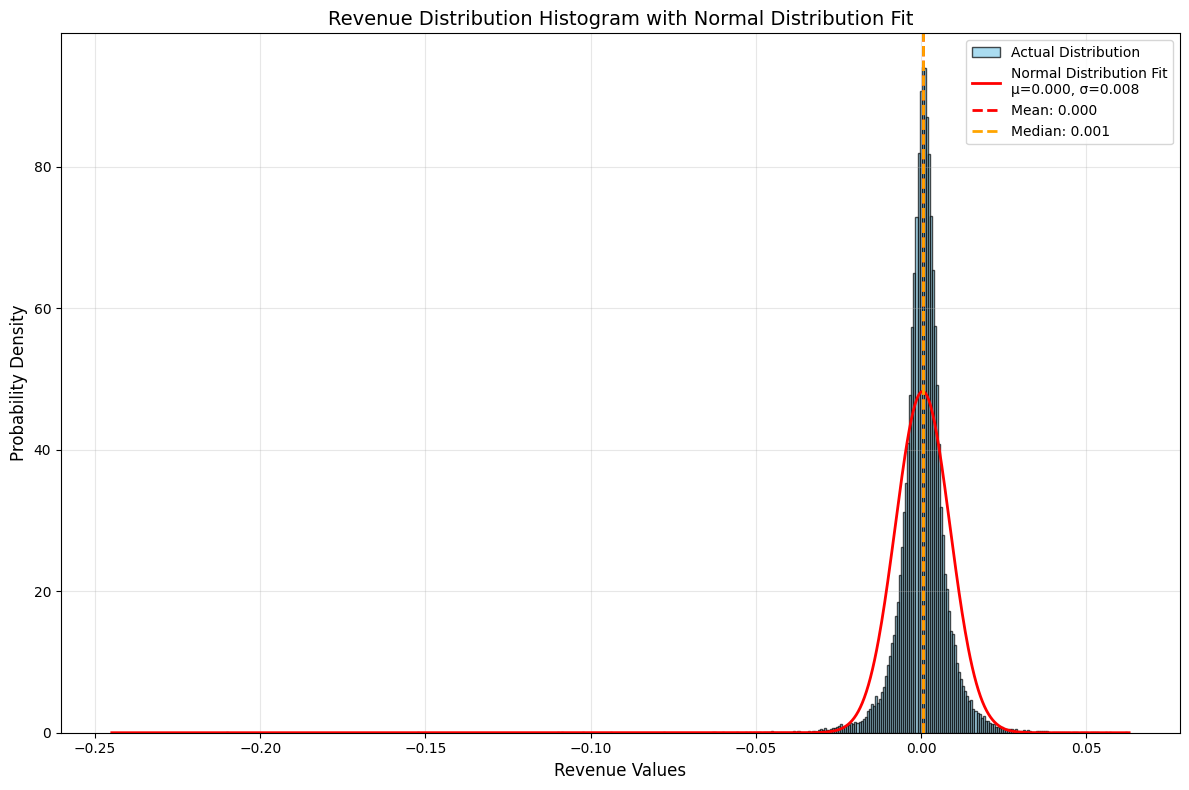


Kolmogorov-Smirnov Normality Test:
Test statistic: 0.1195
p-value: 0.0000e+00
Conclusion: Reject normality assumption

Goodness of Fit:
R² = 0.8058


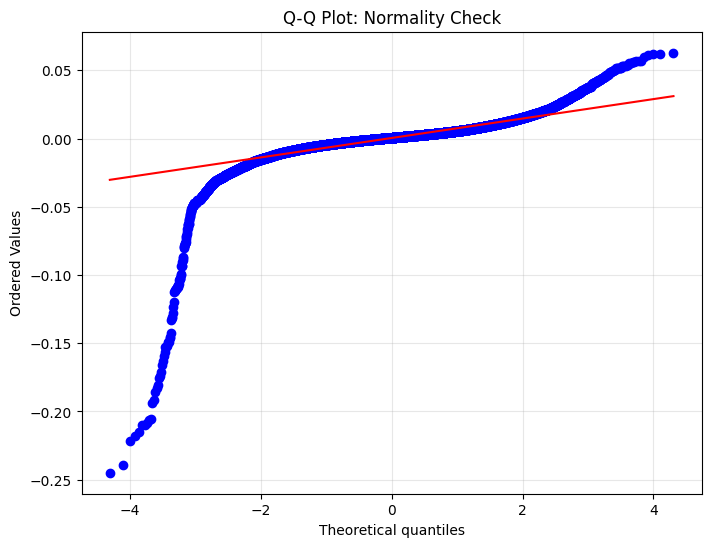


Normal Distribution Fit Results:
Normal Distribution: N(0.0004, 0.0083²)
95% Confidence Interval: [-0.0158, 0.0166]
99% Confidence Interval: [-0.0209, 0.0218]


In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm
import seaborn as sns

# Remove NaN values
revenue_data = np.array(revenues)/50

# Calculate statistics
mean_revenue = np.mean(revenue_data)
std_revenue = np.std(revenue_data, ddof=1)  # Sample standard deviation
median_revenue = np.median(revenue_data)
skewness = stats.skew(revenue_data)
kurtosis = stats.kurtosis(revenue_data)

print(f"Statistics:")
print(f"Sample size: {len(revenues)}")
print(f"Mean (μ): {mean_revenue:.4f}")
print(f"Standard deviation (σ): {std_revenue:.4f}")
print(f"Median: {median_revenue:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Create figure
plt.figure(figsize=(12, 8))

# Plot histogram
n_bins = 500
counts, bins, patches = plt.hist(revenue_data, bins=n_bins, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='Actual Distribution')

# Generate normal distribution fit curve
x = np.linspace(revenue_data.min(), revenue_data.max(), 1000)
fitted_normal = norm.pdf(x, mean_revenue, std_revenue)
plt.plot(x, fitted_normal, 'r-', linewidth=2, 
         label=f'Normal Distribution Fit\nμ={mean_revenue:.3f}, σ={std_revenue:.3f}')

# Add mean and median lines
plt.axvline(mean_revenue, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_revenue:.3f}')
plt.axvline(median_revenue, color='orange', linestyle='--', linewidth=2, 
            label=f'Median: {median_revenue:.3f}')

# Plot settings
plt.xlabel('Revenue Values', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Revenue Distribution Histogram with Normal Distribution Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()

# Kolmogorov-Smirnov normality test
ks_statistic, ks_p_value = stats.kstest(revenue_data, 
                                        lambda x: norm.cdf(x, mean_revenue, std_revenue))

# Shapiro-Wilk normality test (suitable for small samples)
if len(revenue_data) <= 5000:
    sw_statistic, sw_p_value = stats.shapiro(revenue_data)
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test statistic: {sw_statistic:.4f}")
    print(f"p-value: {sw_p_value:.4e}")
    print(f"Conclusion: {'Accept normality assumption' if sw_p_value > 0.05 else 'Reject normality assumption'}")

print(f"\nKolmogorov-Smirnov Normality Test:")
print(f"Test statistic: {ks_statistic:.4f}")
print(f"p-value: {ks_p_value:.4e}")
print(f"Conclusion: {'Accept normality assumption' if ks_p_value > 0.05 else 'Reject normality assumption'}")

# Calculate goodness of fit (R²)
bin_centers = (bins[:-1] + bins[1:]) / 2
expected_counts = len(revenue_data) * norm.pdf(bin_centers, mean_revenue, std_revenue) * (bins[1] - bins[0])
observed_counts = counts * len(revenue_data) * (bins[1] - bins[0])

# Calculate R²
ss_res = np.sum((observed_counts - expected_counts) ** 2)
ss_tot = np.sum((observed_counts - np.mean(observed_counts)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"R² = {r_squared:.4f}")

# Plot Q-Q plot for normality check
plt.figure(figsize=(8, 6))
stats.probplot(revenue_data, dist="norm", plot=plt)
plt.title('Q-Q Plot: Normality Check')
plt.grid(True, alpha=0.3)
plt.show()

# Output normal distribution parameter summary
print(f"\nNormal Distribution Fit Results:")
print(f"Normal Distribution: N({mean_revenue:.4f}, {std_revenue:.4f}²)")
print(f"95% Confidence Interval: [{mean_revenue - 1.96*std_revenue:.4f}, {mean_revenue + 1.96*std_revenue:.4f}]")
print(f"99% Confidence Interval: [{mean_revenue - 2.58*std_revenue:.4f}, {mean_revenue + 2.58*std_revenue:.4f}]")

In [37]:
revenue_series = pd.Series(revenues)

# for stat in stats_global.keys():
#     series = pd.Series(stats_global[stat])
#     revenue_series = revenue_series.iloc[-len(series):]
#     corr = series.corr(revenue_series)
#     print(f"Correlation between {stat} and revenues: {corr:.4f}")
#     # series.to_csv(f"stat_{stat}.csv", index=False)


In [38]:
fit_ratio = 0.8 # 70% 用于训练，30% 用于测试
split_index = int(len(revenue_series) * fit_ratio)
train_revenues = revenue_series[:split_index]
test_revenues = revenue_series[split_index:]
train_revenue_series = np.array(train_revenues)
test_revenue_series = np.array(test_revenues)

train_stats = {}
test_stats = {}
for stat in stats_global.keys():
    series = pd.Series(stats_global[stat])
    if len(series) != len(revenue_series):
        print(f"Length mismatch for {stat}: series length {len(series)}, revenue_series length {len(revenue_series)}")
        series = series[:len(revenue_series)]  # Align lengths by taking the last part of the series
    train_stats[stat] = series[:split_index] 
    test_stats[stat] = series[split_index:]
for stat in stats_by_window.keys():

    for w in windows:

        series = pd.Series(stats_by_window[stat][w])
        if len(series) != len(revenue_series):
            print(f"Length mismatch for {stat} window {w}: series length {len(series)}, revenue_series length {len(revenue_series)}")
            series = series[:len(revenue_series)]  # Align lengths by taking the last part of the series
        train_stats[f"{stat}_w{w}"] = series[:split_index]
        test_stats[f"{stat}_w{w}"] = series[split_index:]            
        print(len(test_stats[f"{stat}_w{w}"]), len(revenue_series))


16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
16657 83281
1665

In [39]:
pd.DataFrame(test_stats)

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
66624,-0.018914,0.003143,0.000985,73.051282,70.0,-3.051282,7.5,0.881036,0.079373,-0.801663,...,0.001522,0.001373,0.000998,-0.001156,-0.001433,-0.001314,-0.001765,-0.001130,-0.001006,-0.000613
66625,-0.020165,0.003313,0.000460,62.846154,62.5,-0.346154,3.5,0.880530,0.071555,-0.808975,...,0.001522,0.001373,0.000998,-0.001143,-0.001421,-0.001187,-0.001767,-0.001130,-0.001006,-0.000613
66626,-0.018908,0.003102,0.000621,66.461538,61.5,-4.961538,5.5,0.879896,0.064580,-0.815316,...,0.001522,0.001373,0.000998,-0.001070,-0.001424,-0.001186,-0.001767,-0.001130,-0.001006,-0.000613
66627,-0.017008,0.002924,0.000240,59.589744,64.0,4.410256,1.5,0.878917,0.054250,-0.824667,...,0.001522,0.001372,0.000998,-0.001057,-0.001425,-0.001185,-0.001766,-0.001130,-0.001006,-0.000613
66628,-0.016311,0.002845,0.000946,73.666667,71.0,-2.666667,6.5,0.877874,0.045769,-0.832105,...,0.001522,0.001373,0.000998,-0.001026,-0.001392,-0.001178,-0.001765,-0.001129,-0.001006,-0.000613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83276,-0.042257,0.005632,-0.001084,45.538462,59.0,13.461538,8.5,0.074809,-0.026445,-0.101254,...,0.001657,0.001297,0.001571,-0.000561,-0.000194,0.000592,0.000411,0.000086,0.000049,0.000025
83277,-0.046266,0.005948,-0.000422,57.897436,60.0,2.102564,3.5,0.081109,-0.032368,-0.113478,...,0.001657,0.001297,0.001571,-0.000576,-0.000199,0.000583,0.000409,0.000086,0.000049,0.000025
83278,-0.041417,0.005534,-0.000538,56.846154,57.5,0.653846,4.5,0.087778,-0.037864,-0.125642,...,0.001659,0.001298,0.001571,-0.000636,-0.000274,0.000552,0.000401,0.000084,0.000049,0.000025
83279,-0.042702,0.005566,-0.000627,54.948718,58.5,3.551282,6.5,0.090562,-0.039196,-0.129758,...,0.001659,0.001298,0.001571,-0.000628,-0.000277,0.000528,0.000399,0.000084,0.000048,0.000025


In [40]:
X_train=pd.DataFrame(train_stats)


X_train


,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


In [41]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# n_bins = 50  # 分箱数量，可调整

# for stat_name, stats in train_stats.items():
#     i = stat_name
#     df = pd.DataFrame({
#         "stats": stats,
#         "revenue": train_revenue_series
#     }).dropna()

#     # 等频分箱（推荐用于分布不均）
#     df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

#     # 分箱统计
#     bin_stats = df.groupby("bin")["revenue"].agg(
#         count="count",
#         mean="mean",
#         median="median",
#         std="std"
#     )

#     # ===== 1. 原始散点图 =====
#     plt.figure(figsize=(10, 6))
#     plt.scatter(df["stats"], df["revenue"], s=1)
#     plt.xlabel("stats")
#     plt.ylabel("revenue")
#     plt.title(f"Scatter Plot (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 2. 分箱箱线图 =====
#     plt.figure(figsize=(12, 6))
#     df.boxplot(
#         column="revenue",
#         by="bin",
#         showfliers=False,
#         grid=False
#     )
#     plt.xticks(rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Revenue")
#     plt.title(f"Binned Boxplot (stats_{i})")
#     plt.suptitle("")
#     plt.show()
#     plt.close()

#     # ===== 3. 分箱均值曲线 =====
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         range(len(bin_stats)),
#         bin_stats["mean"].values,
#         marker="o"
#     )
#     plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Mean revenue")
#     plt.title(f"Binned Mean Revenue (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 4. 输出统计表 =====
#     print(f"\nSummary statistics for stats_{i}:")
#     print(bin_stats)


In [42]:
len(train_revenue_series), len(train_stats['residual_diff'])

(66624, 66624)

In [43]:
test_stats

{'residual_diff': 66624   -0.018914
 66625   -0.020165
 66626   -0.018908
 66627   -0.017008
 66628   -0.016311
            ...   
 83276   -0.042257
 83277   -0.046266
 83278   -0.041417
 83279   -0.042702
 83280   -0.067409
 Length: 16657, dtype: float64,
 'residual_std': 66624    0.003143
 66625    0.003313
 66626    0.003102
 66627    0.002924
 66628    0.002845
            ...   
 83276    0.005632
 83277    0.005948
 83278    0.005534
 83279    0.005566
 83280    0.008846
 Length: 16657, dtype: float64,
 'residual_mean': 66624    0.000985
 66625    0.000460
 66626    0.000621
 66627    0.000240
 66628    0.000946
            ...   
 83276   -0.001084
 83277   -0.000422
 83278   -0.000538
 83279   -0.000627
 83280    0.001437
 Length: 16657, dtype: float64,
 'residual_z_all': 66624    73.051282
 66625    62.846154
 66626    66.461538
 66627    59.589744
 66628    73.666667
            ...    
 83276    45.538462
 83277    57.897436
 83278    56.846154
 83279    54.948718
 83280   

# Factor Model

## Evaluation Function

In [44]:
y_train=train_revenue_series/50 * 10000
X_train=pd.DataFrame(train_stats)

y_test=test_revenue_series/50 * 10000
X_test=pd.DataFrame(test_stats)
def model_evaluation(y_true, y_pred, dataset_type="Train",thres = 5,if_plot=True, if_stats=True):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)

    y_true_filtered = []
    for i in range(len(y_true)):
        if y_pred[i] >thres:
            y_true_filtered.append(y_true[i])
        

    
    # 绘制折线图
    if if_plot:
        plt.figure(figsize=(12, 8))
        
        # 主图：均值对比
        plt.subplot(2, 1, 1)
        plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
        plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
        plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                    label=f'Overall True Mean: {overall_true_mean:.4f}')
        plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                    label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
        plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
                label=f'cost baseline: 10')
        
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Mean Value')
        plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 副图：样本数量
        plt.subplot(2, 1, 2)
        plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Sample Count')
        plt.title('Sample Count by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    if if_stats:
        # 输出基本评估指标
        print(f"{dataset_type} Set Evaluation:")
        print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
        print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Overall True Mean: {overall_true_mean:.4f}")
        print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
        
        # 输出百分位分析表
        percentile_df = pd.DataFrame({
            'Percentile': percentiles,
            'True_Mean': true_means,
            'Pred_Mean': pred_means,
            'Sample_Count': sample_counts,
            'Mean_Diff': np.array(pred_means) - np.array(true_means)
        })
        
        print(f"{dataset_type} Set Percentile Analysis:")
        print(percentile_df.round(4))
    return len(y_true_filtered), np.mean(y_true_filtered),

    # # return percentile_df

In [45]:
len(y_train)

66624

In [46]:
# Check for NaN values in X_test
nan_check = X_train.isna().sum()

# Print columns with NaN values
print("Columns with NaN values:")
print(nan_check[nan_check > 0])

# Fill NaN values with 0
X_train.fillna(0, inplace=True)

Columns with NaN values:
Series([], dtype: int64)


In [47]:
# Check for NaN values in X_test
nan_check = X_test.isna().sum()

# Print columns with NaN values
print("Columns with NaN values:")
print(nan_check[nan_check > 0])

# Fill NaN values with 0
X_test.fillna(0, inplace=True)

Columns with NaN values:
Series([], dtype: int64)


In [48]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]

print(f"Number of rows with infinity values: {inf_mask.sum()}")
print(f"Total rows in X_train: {len(X_train)}")
print(f"Percentage of rows with infinity: {inf_mask.sum() / len(X_train) * 100:.2f}%")

if len(invalid_rows) > 0:
    print("\nRows with infinity values:")
    print(invalid_rows)
    
    # Show which columns contain infinity values
    inf_columns = X_train.columns[np.isinf(X_train).any(axis=0)]
    print(f"\nColumns containing infinity values: {list(inf_columns)}")
    
    # Count infinity values per column
    inf_count_per_column = np.isinf(X_train).sum()
    inf_count_per_column = inf_count_per_column[inf_count_per_column > 0]
    print("\nInfinity count per column:")
    for col, count in inf_count_per_column.items():
        print(f"  {col}: {count}")
    
    # Show first few rows with infinity for inspection
    print(f"\nFirst 5 rows with infinity values:")
    print(invalid_rows.head())
    
else:
    print("No infinity values found in X_train.")

# Method 2: Check for both positive and negative infinity separately
pos_inf_mask = np.isposinf(X_train).any(axis=1)
neg_inf_mask = np.isneginf(X_train).any(axis=1)

print(f"\nRows with positive infinity: {pos_inf_mask.sum()}")
print(f"Rows with negative infinity: {neg_inf_mask.sum()}")

Checking for infinity values in X_train...
Number of rows with infinity values: 0
Total rows in X_train: 66624
Percentage of rows with infinity: 0.00%
No infinity values found in X_train.

Rows with positive infinity: 0
Rows with negative infinity: 0


In [49]:
X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


## Linear

In [50]:
len(X_test)

16657

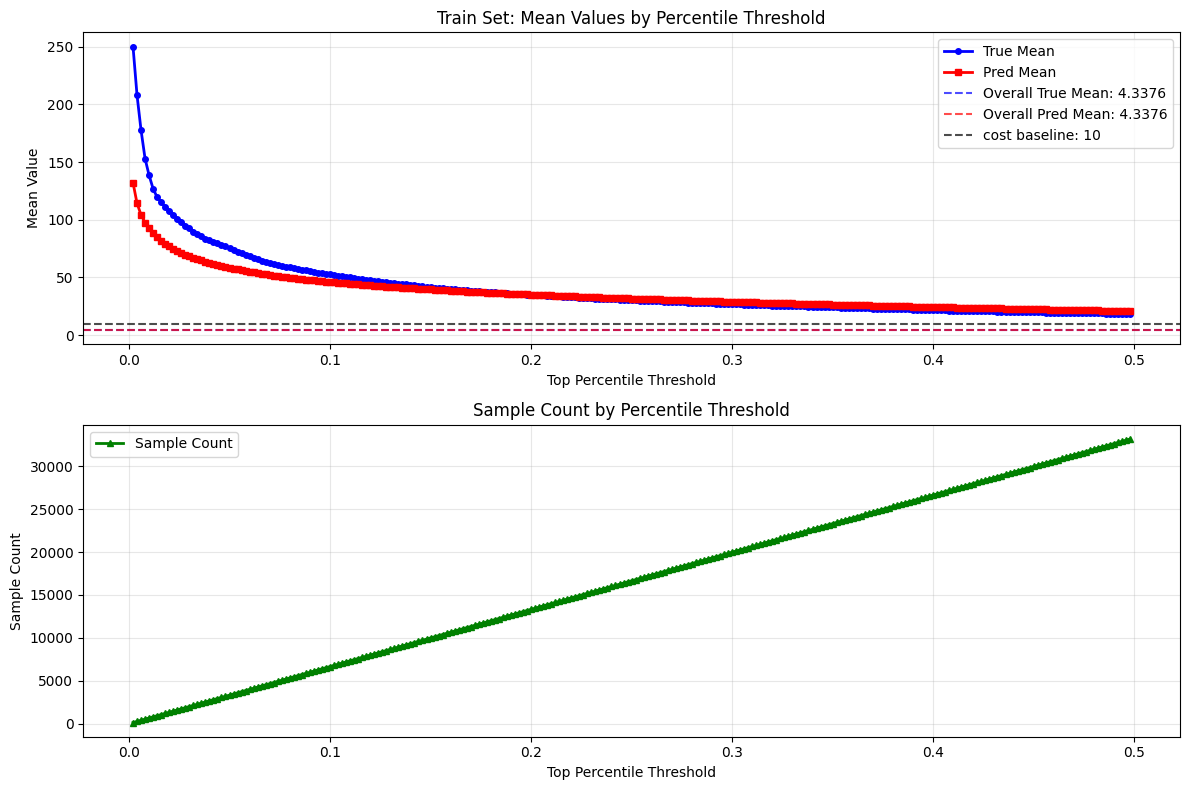

Train Set Evaluation:
  MAE: 45.2468, Relative MAE: 0.6537
  RMSE: 65.6076, Relative RMSE: 0.9478
  R²: 0.1017
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3376

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   250.1689   132.1283           134  -118.0406
1         0.004   207.9165   114.2665           267   -93.6500
2         0.006   177.5947   104.1925           400   -73.4022
3         0.008   152.9464    97.4997           533   -55.4468
4         0.010   138.5082    92.4024           667   -46.1058
..          ...        ...        ...           ...        ...
244       0.490    18.5423    21.0080         32646     2.4657
245       0.492    18.4805    20.9390         32779     2.4585
246       0.494    18.4029    20.8702         32912     2.4673
247       0.496    18.3574    20.8009         33046     2.4435
248       0.498    18.3084    20.7324         33179     2.4239

[249 rows x 5 columns]


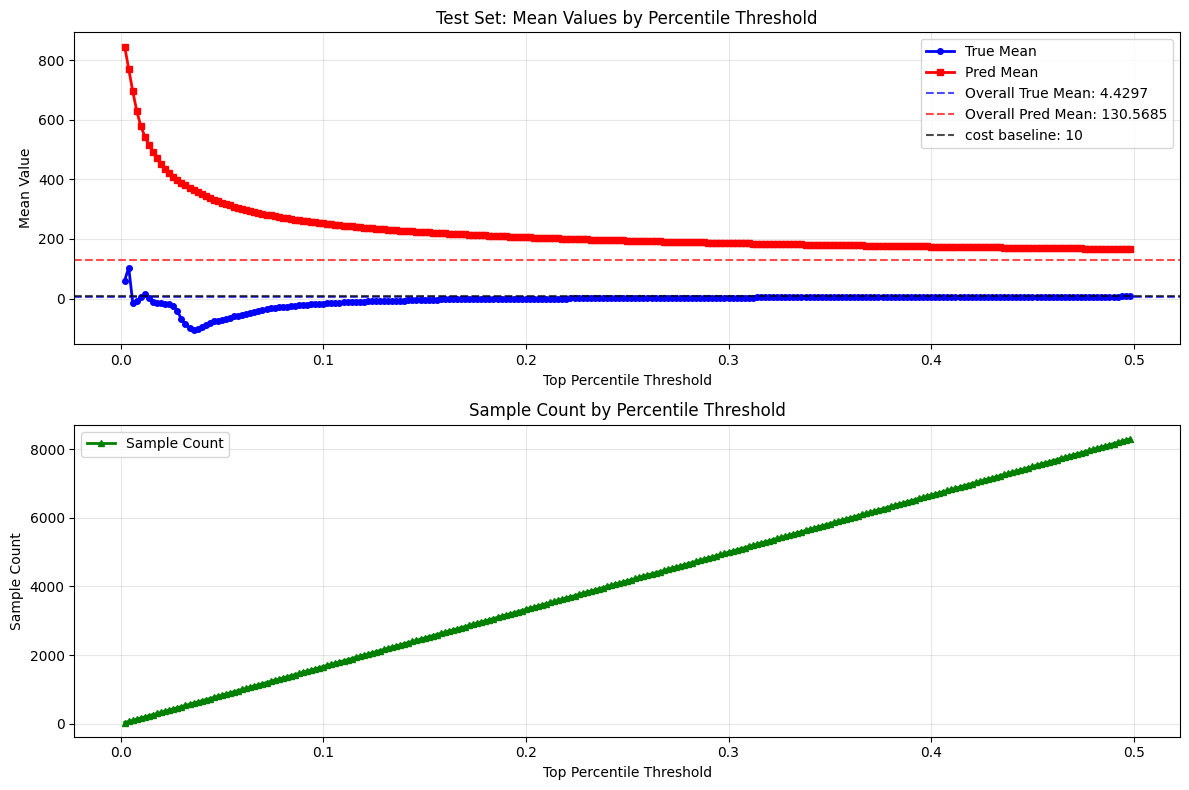

Test Set Evaluation:
  MAE: 135.1708, Relative MAE: 1.1032
  RMSE: 189.0226, Relative RMSE: 1.5427
  R²: -1.3800
  Overall True Mean: 4.4297
  Overall Pred Mean: 130.5685

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    60.4052   846.5109            34   786.1057
1         0.004   103.8452   771.4962            67   667.6509
2         0.006   -14.1496   695.9330           100   710.0826
3         0.008    -8.7442   628.4544           134   637.1986
4         0.010     4.5991   578.7580           167   574.1589
..          ...        ...        ...           ...        ...
244       0.490     6.6725   166.8217          8162   160.1492
245       0.492     6.6868   166.6698          8195   159.9830
246       0.494     6.7349   166.5139          8229   159.7791
247       0.496     6.7461   166.3631          8262   159.6171
248       0.498     6.7606   166.2130          8295   159.4524

[249 rows x 5 columns]


(16628, np.float64(4.39041466782307))

In [51]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)
model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")


## Rolling Window

In [52]:
# def evaluate_ratio_batch(X_all, y_all, ratio: int, batch: int):
#     nums = []
#     means = []
#     for i in range(0, len(y_all), batch):
#         if i + (ratio+1)*batch > len(y_all):
#             break
#         X_batch = X_all.iloc[i:i+ratio*batch]
#         y_batch = y_all[i:i+ratio*batch]
#         X_next = X_all.iloc[i+ratio*batch:i+(ratio+1)*batch]
#         y_next = y_all[i+ratio*batch:i+(ratio+1)*batch]
#         model  = LinearRegression()
#         model.fit(X_batch, y_batch)
#         y_next_pred = model.predict(X_next)
#         # print(f"--------------------- Batch {i//batch + 1} ---------------------")
#         n,m=model_evaluation(y_next, y_next_pred, thres=20, dataset_type=f"Batch {i//batch + 1}", if_plot=False, if_stats=False)
#         nums.append(n)
#         means.append(m)
#     nm_df = pd.DataFrame({
#         "num": nums,
#         "mean": means,
#         "mult": np.array(nums)*np.array(means)
#     })
#     mean_rev = nm_df["mult"].sum()/nm_df["num"].sum()
#     pct = nm_df["num"].sum()/len(y_all)
#     pos = 1 if mean_rev > 5 and pct > 0.005 else -1
#     score = abs((mean_rev-5) * (pct-0.005))*pos
#     if not np.isfinite(score):
#         return 0.0
#     print(f"[DEBUG][EVAL] ratio={ratio}, batch={batch}, score={score:.6f}, mean={mean_rev:.3f}, pct={pct:.3f}")
#     return score

# def grad_ratio(X_all, y_all, ratio, batch):
#     f0 = evaluate_ratio_batch(X_all, y_all, ratio, batch)
#     f_plus = evaluate_ratio_batch(X_all, y_all, ratio + 10, batch)

#     if ratio > 10:
#         f_minus = evaluate_ratio_batch(X_all, y_all, ratio - 10, batch)
#         g = 0.5 * (f_plus - f_minus)
#     else:
#         g = f_plus - f0
#     print(f"[DEBUG][GRAD_RATIO] r={ratio}, g={g:.6f}, f+={f_plus:.6f}, f0={f0:.6f}")
#     return g if np.isfinite(g) else 0.0

# def grad_batch(X_all, y_all, ratio, batch):
#     f0 = evaluate_ratio_batch(X_all, y_all, ratio, batch)
#     f_plus = evaluate_ratio_batch(X_all, y_all, ratio, batch + 150)

#     if batch > 150:
#         f_minus = evaluate_ratio_batch(X_all, y_all, ratio, batch - 150)
#         g = 0.5 * (f_plus - f_minus)
#     else:
#         g = f_plus - f0
#     print(f"[DEBUG][GRAD_BATCH] b={batch}, g={g:.6f}, f+={f_plus:.6f}, f0={f0:.6f}")
#     return g if np.isfinite(g) else 0.0


# def update_param(x, grad, lr, x_min, x_max):
#     if not np.isfinite(grad):
#         return x

#     x_new = x + lr * grad

#     if not np.isfinite(x_new):
#         return x

#     x_new = int(round(x_new))
#     print(f"[DEBUG][UPDATE] x={x}, grad={grad:.6f}, lr={lr}, new={x_new}")
#     return int(np.clip(x_new, x_min, x_max))
# def gd_optimize_ratio_batch_pm1(
#     X_all, y_all,
#     ratio_init=2,
#     batch_init=1000,
#     lr_ratio=50.0,
#     lr_batch=50.0,
#     ratio_min=1,
#     ratio_max=50,
#     batch_min=200,
#     batch_max=10000,
#     n_iters=20
# ):
#     ratio, batch = ratio_init, batch_init
#     history = []

#     for t in range(n_iters):
#         g_r = grad_ratio(X_all, y_all, ratio, batch)
#         g_b = grad_batch(X_all, y_all, ratio, batch)

#         ratio = update_param(ratio, g_r, lr_ratio, ratio_min, ratio_max)
#         batch = update_param(batch, g_b, lr_batch, batch_min, batch_max)

#         score = evaluate_ratio_batch(X_all, y_all, ratio, batch)

#         history.append({
#             "iter": t,
#             "ratio": ratio,
#             "batch": batch,
#             "grad_ratio": g_r,
#             "grad_batch": g_b,
#             "score": score
#         })
#         print("========================================= ")

#         print(f"Iter {t}: ratio={ratio}, batch={batch}, score={score:.4f}")

#     return pd.DataFrame(history)



# X_all = pd.concat([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])

# df_hist = gd_optimize_ratio_batch_pm1(
#     X_all, y_all,
#     ratio_init=20,
#     batch_init=2000,
#     lr_ratio=100.0,
#     lr_batch=5000.0,
#     n_iters=20
# )

# print(df_hist)


In [53]:
# X_all = pd.concat([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])

# ratio = 30
# batch = 2500


# nums = []
# means = []
# for i in range(0, len(y_all), batch):
#     if i + (ratio+1)*batch > len(y_all):
#         break
#     X_batch = X_all.iloc[i:i+ratio*batch]
#     y_batch = y_all[i:i+ratio*batch]
#     X_next = X_all.iloc[i+ratio*batch:i+(ratio+1)*batch]
#     y_next = y_all[i+ratio*batch:i+(ratio+1)*batch]
#     model  = LinearRegression()
#     model.fit(X_batch, y_batch)
#     y_next_pred = model.predict(X_next)
#     # print(f"--------------------- Batch {i//batch + 1} ---------------------")
#     n,m=model_evaluation(y_next, y_next_pred, thres=25, dataset_type=f"Batch {i//batch + 1}", if_plot=False, if_stats=False)
#     nums.append(n)
#     means.append(m)
# nm_df = pd.DataFrame({
#     "num": nums,
#     "mean": means,
#     "mult": np.array(nums)*np.array(means)
# })
# mean_rev = nm_df["mult"].sum()/nm_df["num"].sum()
# pct = nm_df["num"].sum()/len(y_all)
# score = (mean_rev-5) * pct
# print(f"Mean revenue above threshold: {mean_rev:.4f}, Percentage of samples: {pct:.4f}, Score: {score:.4f}")

In [54]:
# mult_cum = nm_df["mult"].cumsum()
# plt.figure(figsize=(10, 6))
# plt.plot(mult_cum)
# plt.xlabel("Batches")
# plt.ylabel("Cumulative Mean Revenue")
# plt.title("Cumulative Mean Revenue over Batches")
# plt.grid(True, alpha=0.3)
# plt.show()

## ML

In [55]:
# Convert numpy arrays to pandas DataFrames or Series
y_train_df = pd.DataFrame(y_train, columns=["y_train"])
y_test_df = pd.DataFrame(y_test, columns=["y_test"])

# Save to CSV
X_train.to_csv("X_train_1.csv", index=False)
y_train_df.to_csv("y_train_1.csv", index=False)
X_test.to_csv("X_test_1.csv", index=False)
y_test_df.to_csv("y_test_1.csv", index=False)

In [56]:
# import numpy as np
# import lightgbm as lgb
# from sklearn.metrics import mean_squared_error

# # ===============================
# # 1. 随机划分 80% / 20%（模拟你原来的 90/10 early stop）
# # ===============================
# random_index = np.random.permutation(len(X_train))
# split = int(0.8 * len(X_train))

# X_train_80 = X_train.iloc[random_index[:split]]
# y_train_80 = y_train[random_index[:split]]

# X_train_20 = X_train.iloc[random_index[split:]]
# y_train_20 = y_train[random_index[split:]]

# # ===============================
# # 2. 定义 LightGBM 回归模型
# # ===============================
# model = lgb.LGBMRegressor(
#     objective="regression",
#     metric="mse",
#     boosting_type="gbdt",

#     n_estimators=5000,        # 给足树数，early stopping 决定最终用多少
#     learning_rate=0.03,

#     num_leaves=31,            # 4 维特征的稳妥取值
#     max_depth=-1,

#     min_data_in_leaf=200,     # 防止过拟合（≈ RF 的 min_samples_leaf）
#     min_gain_to_split=0.0,

#     subsample=0.8,            # ≈ max_samples
#     subsample_freq=1,
#     colsample_bytree=0.8,     # ≈ max_features

#     reg_lambda=1.0,

#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

# # ===============================
# # 3. 训练（Early Stopping）
# # ===============================
# print("Training LightGBM with early stopping...")

# model.fit(
#     X_train_80,
#     y_train_80,
#     eval_set=[(X_train_20, y_train_20)],
#     eval_metric="mse",
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=100, verbose=True)
#     ]
# )

# # ===============================
# # 4. 验证集评估
# # ===============================
# val_pred = model.predict(X_train_20, num_iteration=model.best_iteration_)
# val_mse = mean_squared_error(y_train_20, val_pred)

# print(f"Validation MSE: {val_mse:.6f}")
# print(f"Best iteration: {model.best_iteration_}")

# # ===============================
# # 5. 全量预测
# # ===============================
# y_train_pred = model.predict(X_train, num_iteration=model.best_iteration_)
# y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

# # ===============================
# # 6. 可选：特征重要性
# # ===============================
# feature_importance = model.feature_importances_

# print("Feature importance:", feature_importance)


In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=250,
    
    max_samples=0.8,
    max_features=0.8,
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_index = np.random.permutation(len(X_train))
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[random_index[:split]]
y_train_80 = y_train[random_index[:split]]

X_train_20 = X_train.iloc[random_index[split:]]
y_train_20 = y_train[random_index[split:]]

# 训练模型
print("Training Random Forest...")
model.fit(X_train_80, y_train_80)

# 验证集评估
val_pred = model.predict(X_train_20)
val_mse = mean_squared_error(y_train_20, val_pred)
print(f"Validation MSE: {val_mse:.6f}")

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

print("Feature importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"  {name}: {importance:.4f}")

Training Random Forest...
Validation MSE: 3933.205798
Feature importance:
  residual_diff: 0.1771
  residual_std: 0.0021
  residual_mean: 0.0002
  residual_z_all: 0.0000
  residual_z_selected: 0.0000
  residual_z_selected_mns: 0.0001
  residual_sign: 0.0001
  corr_all: 0.0028
  corr_selected: 0.0030
  corr_selected_mns: 0.0065
  coef_adj_all: 0.0001
  coef_adj_selected: 0.0010
  coef_adj_selected_mns: 0.0090
  close_ret_all_w30: 0.0001
  close_ret_all_w60: 0.0005
  close_ret_all_w120: 0.0013
  close_ret_all_w480: 0.0019
  close_ret_all_w1920: 0.0494
  close_ret_all_w7680: 0.0042
  close_ret_all_w30720: 0.0104
  close_ret_selected_w30: 0.0002
  close_ret_selected_w60: 0.0009
  close_ret_selected_w120: 0.0002
  close_ret_selected_w480: 0.0077
  close_ret_selected_w1920: 0.0027
  close_ret_selected_w7680: 0.0021
  close_ret_selected_w30720: 0.0026
  close_ret_selected_mns_w30: 0.0072
  close_ret_selected_mns_w60: 0.0045
  close_ret_selected_mns_w120: 0.0644
  close_ret_selected_mns_w480: 

In [58]:
# import pickle

# # 保存模型
# with open('random_forest_model.pkl', 'wb') as f:
#     pickle.dump(model, f)

# print("Model saved as random_forest_model.pkl")

In [59]:
# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Create a list of (name, importance) pairs and sort by importance (descending)
feature_importance_pairs = list(zip(feature_names, feature_importance))
feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

print("Feature importance (sorted by importance):")
for name, importance in feature_importance_pairs:
    print(f"  {name}: {importance:.40f}")

# Alternative: Create a DataFrame for easier manipulation
import pandas as pd

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance_df.head(10).to_string(index=False))

Feature importance (sorted by importance):
  residual_diff: 0.1771279504806493043655990504703368060291
  close_ret_selected_mns_w120: 0.0643823895899765935579850406611512880772
  cmi_all_w1920: 0.0639343102021636550125194276006368454546
  close_ret_all_w1920: 0.0494480092843325377827135014285886427388
  std_all_w30720: 0.0477301151805330572952534851083328248933
  cmi_all_w30720: 0.0452273329317565073171003575680515496060
  coin_selected_w480: 0.0433727760472269394109723350538843078539
  cmi_all_w7680: 0.0402341875881267185821599241535295732319
  atr_selected_mns_w120: 0.0262219876036430751820027751364250434563
  bb_all_w30720: 0.0252386429976916223938410155369638232514
  close_ret_selected_mns_w480: 0.0184723796866004888461709754210460232571
  bb_selected_mns_w7680: 0.0176256249763250029405359242673512198962
  coin_selected_w120: 0.0144383478777298217970992411096631258260
  std_selected_mns_w60: 0.0106113932628833541882418245450026006438
  close_ret_all_w30720: 0.0104213818604638411985

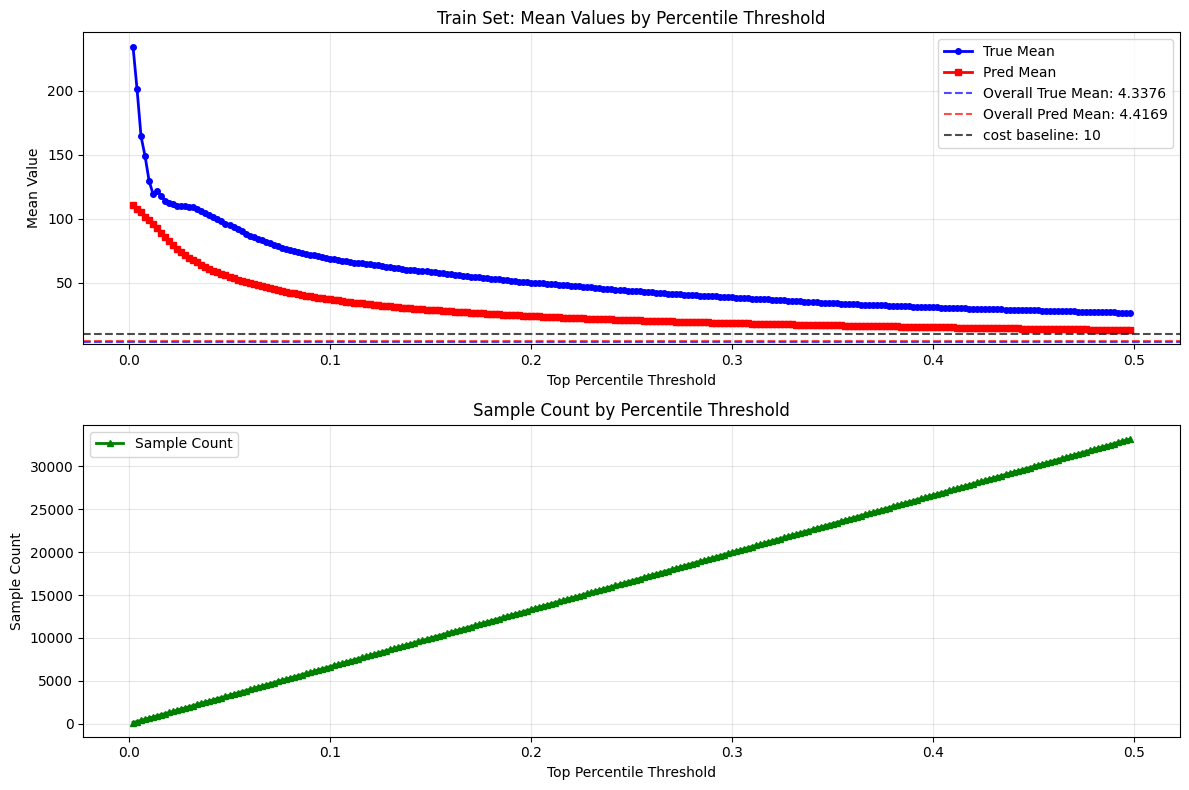

Train Set Evaluation:
  MAE: 42.7932, Relative MAE: 0.6182
  RMSE: 62.5192, Relative RMSE: 0.9032
  R²: 0.1843
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.4169

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   234.4395   110.6989           148  -123.7406
1         0.004   201.2796   107.9082           269   -93.3714
2         0.006   164.2928   104.9884           400   -59.3044
3         0.008   148.8911   101.8235           533   -47.0676
4         0.010   129.6474    99.0592           667   -30.5882
..          ...        ...        ...           ...        ...
244       0.490    27.0250    13.4693         32646   -13.5557
245       0.492    26.9483    13.4284         32779   -13.5199
246       0.494    26.8449    13.3878         32912   -13.4571
247       0.496    26.7778    13.3470         33046   -13.4307
248       0.498    26.6862    13.3068         33179   -13.3793

[249 rows x 5 columns]


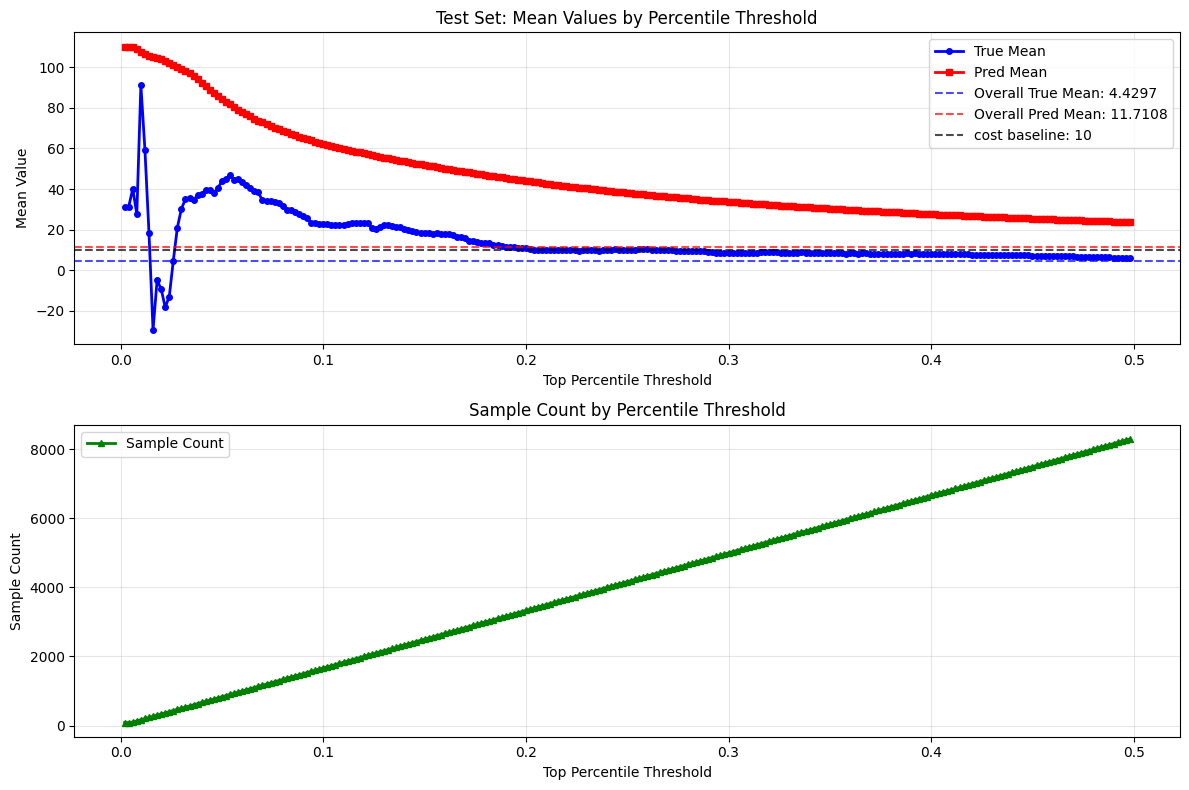

Test Set Evaluation:
  MAE: 56.4579, Relative MAE: 0.4608
  RMSE: 124.0126, Relative RMSE: 1.0121
  R²: -0.0244
  Overall True Mean: 4.4297
  Overall Pred Mean: 11.7108

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    31.3473   110.1965            86    78.8492
1         0.004    31.3473   110.1965            86    78.8492
2         0.006    40.0722   110.1088           100    70.0365
3         0.008    27.7145   108.7286           134    81.0141
4         0.010    91.2532   107.4272           167    16.1739
..          ...        ...        ...           ...        ...
244       0.490     6.2340    23.9858          8162    17.7518
245       0.492     6.1825    23.9173          8195    17.7348
246       0.494     6.1410    23.8471          8229    17.7062
247       0.496     6.1577    23.7795          8262    17.6218
248       0.498     6.1645    23.7123          8295    17.5478

[249 rows x 5 columns]


(12717, np.float64(4.547620017594489))

In [60]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

Average of non-zero true values (filtered by predicted > 20): 23.6168662936789
Percentage of non-zero true values (filtered by predicted > 20): 21.516479558143722


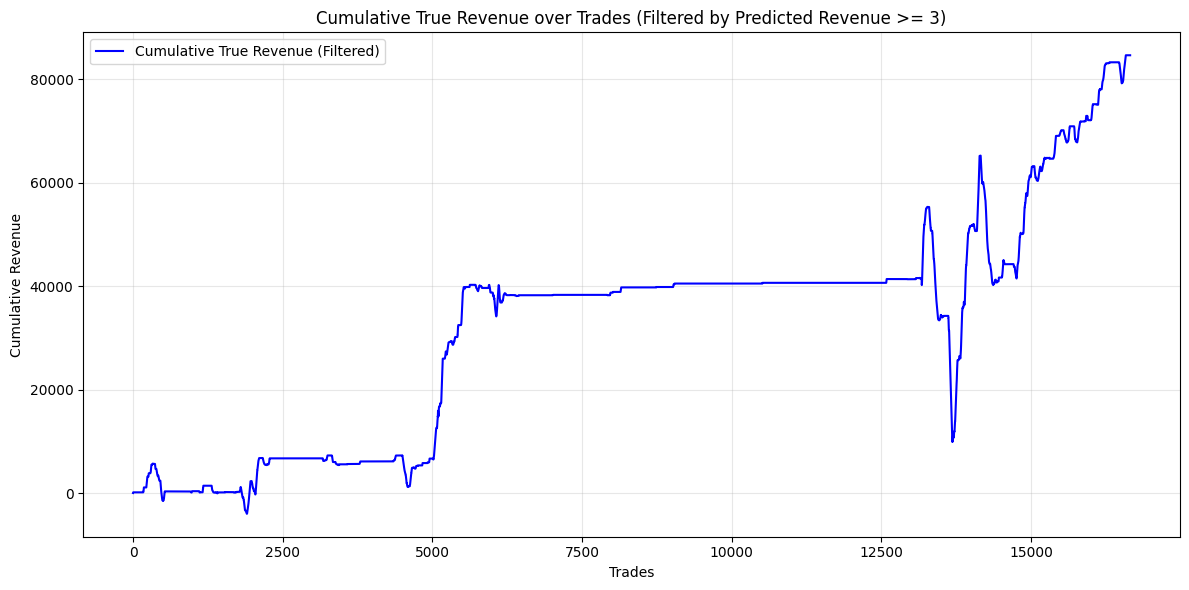

In [70]:
y_true_filtered = []
for i in range(len(y_test)):
    if y_test_pred[i] >15:
        y_true_filtered.append(min(400,max(-400,y_test[i])))
    else:
        y_true_filtered.append(0)

non_zero_avg = np.mean([val for val in y_true_filtered if val != 0])
non_zero_pct = len([val for val in y_true_filtered if val != 0]) / len(y_true_filtered) * 100
print("Average of non-zero true values (filtered by predicted > 20):", non_zero_avg)
print("Percentage of non-zero true values (filtered by predicted > 20):", non_zero_pct)
y_true_filtered_cumsum = np.cumsum(y_true_filtered)

plt.figure(figsize=(12, 6))
plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
plt.xlabel('Trades')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [62]:
# y_true_filtered_cumsum = np.cumsum(y_true_filtered)

# plt.figure(figsize=(12, 6))
# plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
# plt.xlabel('Trades')
# plt.ylabel('Cumulative Revenue')
# plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
# plt.close()

In [63]:

# for stat_name, stats in test_stats.items():
#     i = stat_name
#     df = pd.DataFrame({
#         "stats": stats,
#         "revenue": test_revenue_series
#     }).dropna()

#     # 等频分箱（推荐用于分布不均）
#     df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

#     # 分箱统计
#     bin_stats = df.groupby("bin")["revenue"].agg(
#         count="count",
#         mean="mean",
#         median="median",
#         std="std"
#     )

#     # ===== 1. 原始散点图 =====
#     plt.figure(figsize=(10, 6))
#     plt.scatter(df["stats"], df["revenue"], s=1)
#     plt.xlabel("stats")
#     plt.ylabel("revenue")
#     plt.title(f"Scatter Plot (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 2. 分箱箱线图 =====
#     plt.figure(figsize=(12, 6))
#     df.boxplot(
#         column="revenue",
#         by="bin",
#         showfliers=False,
#         grid=False
#     )
#     plt.xticks(rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Revenue")
#     plt.title(f"Binned Boxplot (stats_{i})")
#     plt.suptitle("")
#     plt.show()
#     plt.close()

#     # ===== 3. 分箱均值曲线 =====
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         range(len(bin_stats)),
#         bin_stats["mean"].values,
#         marker="o"
#     )
#     plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Mean revenue")
#     plt.title(f"Binned Mean Revenue (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 4. 输出统计表 =====
#     print(f"\nSummary statistics for stats_{i}:")
#     print(bin_stats)
